In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'SRF gun simulation',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '250',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '24',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"data": 10}',
    ]
)

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=0.359851, valid=0.027680, test=0.027681
	validation loss decreased (inf -> 0.027680), saving model ...
	epoch 2 losses: train=0.356056, valid=0.027782, test=0.027025
	early stopping counter: 1 out of 10
	epoch 3 losses: train=0.351652, valid=0.028987, test=0.028822
	early stopping counter: 2 out of 10
	epoch 4 losses: train=0.340629, valid=0.032335, test=0.033103
	early stopping counter: 3 out of 10
	epoch 5 losses: train=0.316121, valid=0.030875, test=0.031163
	early stopping counter: 4 out of 10
	epoch 6 losses: train=0.285171, valid=0.028786, test=0.028303
	early stopping counter: 5 out of 10
	epoch 7 losses: train=0.251325, valid=0.026927, test=0.025744
	validation loss decreased (0.027680 -> 0.026927), saving model ...
	epoch 8 losses: train=0.223710, valid=0.025451, test=0.025128
	validation loss decreased (0.026927 -> 0.025451), saving model ...
	epoch 9 losses: train=0.215340, valid=0.026100, test=0.025550
	early stopping cou

In [6]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

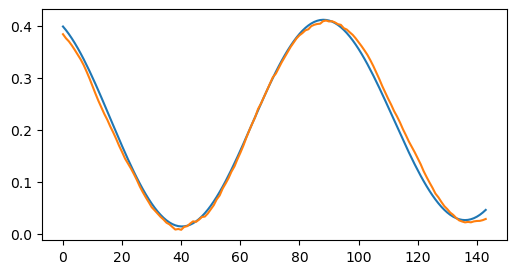

In [7]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [8]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.587070, valid=0.463095, test=0.455256
	validation loss decreased (inf -> 0.463095), saving model ...
	epoch 2 losses: train=0.377689, valid=0.240945, test=0.230111
	validation loss decreased (0.463095 -> 0.240945), saving model ...
	epoch 3 losses: train=0.150931, valid=0.022147, test=0.002681
	validation loss decreased (0.240945 -> 0.022147), saving model ...
	epoch 4 losses: train=-0.091237, valid=-0.160755, test=-0.196355
	validation loss decreased (0.022147 -> -0.160755), saving model ...
	epoch 5 losses: train=-0.354114, valid=-0.261561, test=-0.319304
	validation loss decreased (-0.160755 -> -0.261561), saving model ...
	epoch 6 losses: train=-0.522088, valid=-0.295174, test=-0.356095
	validation loss decreased (-0.261561 -> -0.295174), saving model ...
	epoch 7 losses: train=-0.585996, valid=-0.360753, test=-0.416980
	validation loss decreased (-0.295174 -> -0.360753), saving model ...
	epoch 8 losses: train=-0.621403

In [9]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

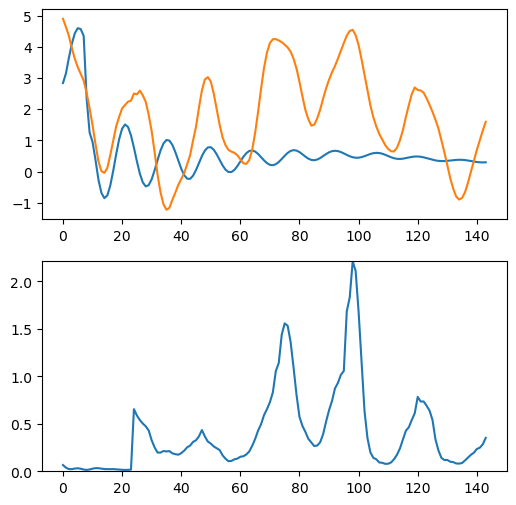

In [10]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [11]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=0.269314, valid=2.266134, test=2.257615
	validation loss decreased (inf -> 2.266134), saving model ...
	epoch 2 losses: train=0.201244, valid=1.807473, test=1.865197
	validation loss decreased (2.266134 -> 1.807473), saving model ...
	epoch 3 losses: train=0.168780, valid=1.669659, test=1.708136
	validation loss decreased (1.807473 -> 1.669659), saving model ...
	epoch 4 losses: train=0.146546, valid=1.574143, test=1.584887
	validation loss decreased (1.669659 -> 1.574143), saving model ...
	epoch 5 losses: train=0.132241, valid=1.466136, test=1.502959
	validation loss decreased (1.574143 -> 1.466136), saving model ...
	epoch 6 losses: train=0.122801, valid=1.411938, test=1.419234
	validation loss decreased (1.466136 -> 1.411938), saving model ...
	epoch 7 losses: train=0.115862, valid=1.355480, test=1.372212
	validation loss decreased (1.411938 -> 1.355480), saving model ...
	epoch 8 losses: train=0.112102, valid=1.330913, test=1.364

In [12]:
model.eval()
_, _, data_loader = dataset.load(data_type='trans')

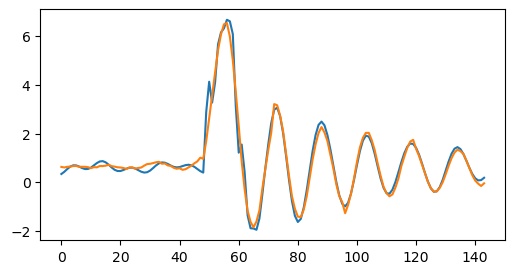

In [13]:
jdata = 22

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [14]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=0.520057, valid=0.431276, test=0.429570
	validation loss decreased (inf -> 0.431276), saving model ...
	epoch 2 losses: train=0.311948, valid=0.191744, test=0.192722
	validation loss decreased (0.431276 -> 0.191744), saving model ...
	epoch 3 losses: train=0.036332, valid=-0.072152, test=-0.049540
	validation loss decreased (0.191744 -> -0.072152), saving model ...
	epoch 4 losses: train=-0.229002, valid=-0.244094, test=-0.185373
	validation loss decreased (-0.072152 -> -0.244094), saving model ...
	epoch 5 losses: train=-0.392168, valid=-0.338568, test=-0.258920
	validation loss decreased (-0.244094 -> -0.338568), saving model ...
	epoch 6 losses: train=-0.501809, valid=-0.409960, test=-0.321929
	validation loss decreased (-0.338568 -> -0.409960), saving model ...
	epoch 7 losses: train=-0.576185, valid=-0.437820, test=-0.338762
	validation loss decreased (-0.409960 -> -0.437820), saving model ...
	epoch 8 losses: train=-0.630

In [15]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

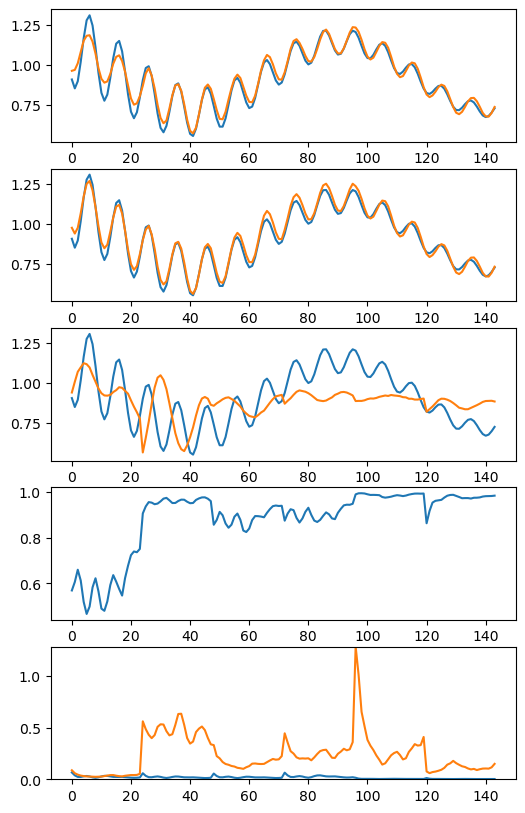

In [22]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break